# Task 1
As a warm up, implement a discrete approximation of small diﬀerential equation system.

(a) The pendulum: the movement of a pendulum can be described via the system of first order ordinary
diﬀerential equations: 

$(\dot{\phi}, \dot{\omega}) = (\omega, -\frac{g}{l}*sin\phi)$

Compare and visualize your results with a standard solver (readily available in your platform). Discuss
any diﬀerences if necessary.

## Parameters:

- $\phi \ \hat{=}$ the angle of the pendulum, where $\phi = 0$ refers to its resting position
- $\omega \ \hat{=}$ the angular velocity (how fast the angle is changing)
- $g$ (gravity)
- $l$ (length of the pendulum)


## Differential Equation

- $\dot{\phi}=\omega$ by definition
- $\dot{\omega}=-\frac{g}{l}*sin\phi$ by physical laws (acceleration)

# Solutions

In [130]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

In [131]:
# Parameterization

phi_0 = np.radians(90)    # pendulum's initial position (degrees -> radiants)
omega_0 = 0.0             # pendulum's initial velocity (FIXED)

g = 9.81    # gravity (m/s^2)
l = 1.0     # pendulum's length (m)  

dt = 0.01       # step size (s)
t_total = 10.0  # total time (s)

## Method
In general, the method determines how we estimate the next position from the current one. Thus, given $\phi$ and $\omega$ at time $t$, we estimate $\phi$ and $\omega$ for $t+dt$.

**Euler**

$\phi_{new} = \phi+\dot{\phi}*dt, \\
\omega_{new} = \omega+\dot{\omega}*dt$

In [132]:
# Calculation

def pendulum_euler(phi, omega, g, l, dt, t_total):

    phi_list = [phi]
    omega_list = [omega]
    t_list = np.arange(0, t_total + dt, dt)

    for t in np.arange(0, t_total, dt):

        # Differential Equation
        phi_dt = omega
        omega_dt = -(g / l) * np.sin(phi)

        # Method (Euler)
        phi = phi + phi_dt * dt
        omega = omega + omega_dt * dt

        # Store results
        phi_list.append(phi)
        omega_list.append(omega)

    # Return results
    return (t_list, np.degrees(phi_list), omega_list)

results_euler = pendulum_euler(phi_0, omega_0, g, l, dt, t_total)

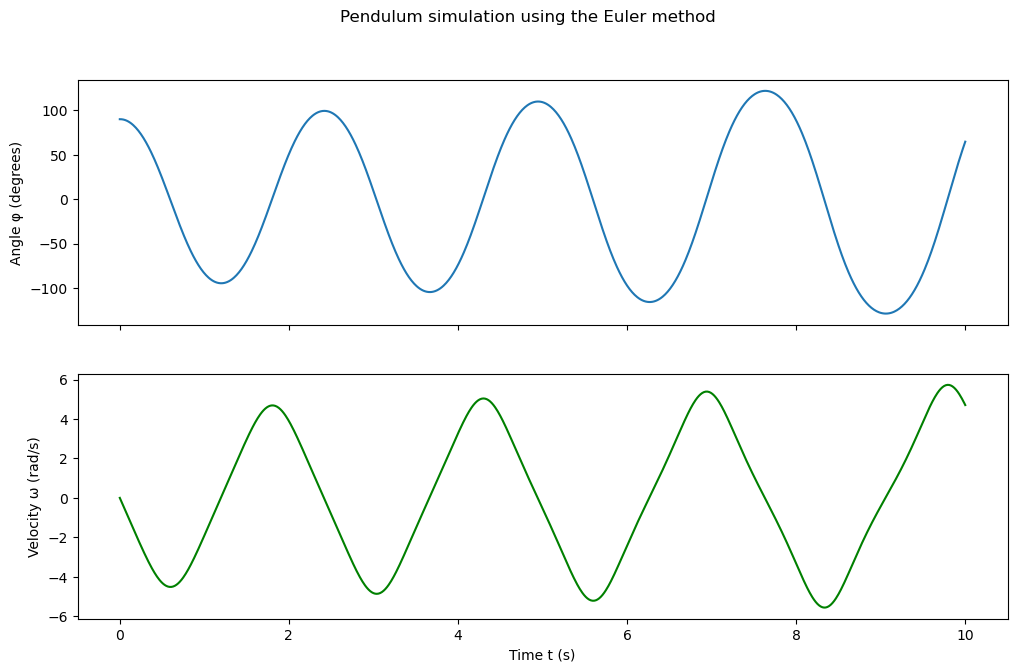

In [133]:
# Visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 7), sharex = True)

ax1.plot(results_euler[0], results_euler[1])
ax1.set_ylabel('Angle φ (degrees)')

ax2.plot(results_euler[0], results_euler[2], color = 'green')
ax2.set_xlabel('Time t (s)')
ax2.set_ylabel('Velocity ω (rad/s)')

plt.suptitle('Pendulum simulation using the Euler method')

plt.show()
plt.close()

## Standard Solver

We utilize the scipy library by passing the differential equation to the solve_ivp method.

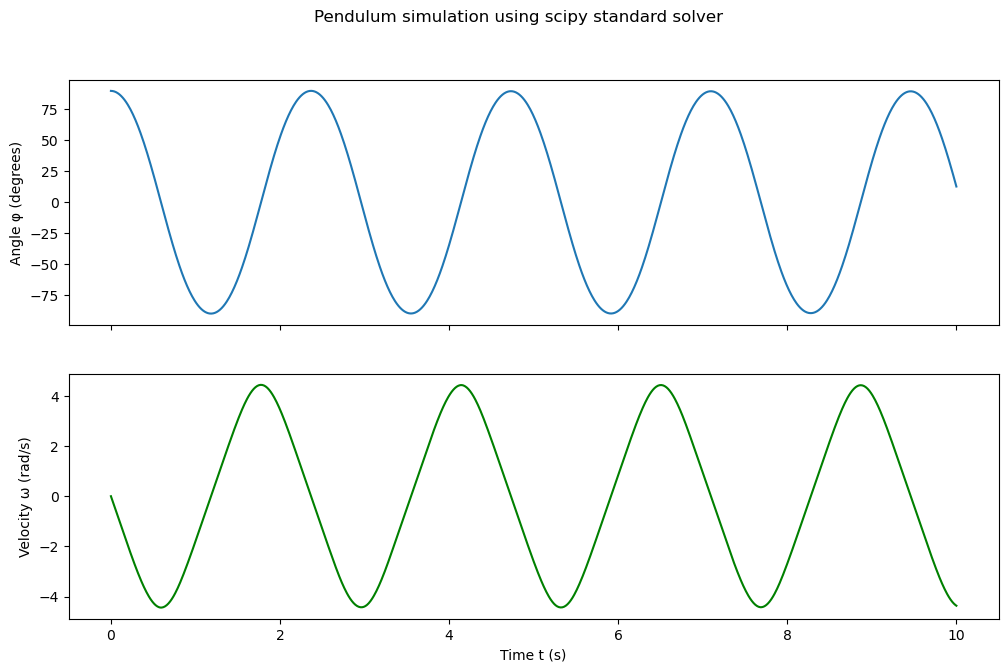

In [134]:
# Import
from scipy.integrate import solve_ivp


# Calculation

def pendulum_scipy(phi, omega, g, l, dt, t_total):

    t_list = np.arange(0, t_total + dt, dt)

    def pendulum(t, y):
        phi, omega = y
        return [omega, -(g / l) * np.sin(phi)]

    solution = solve_ivp(
        pendulum,
        t_span = (0, t_list[-1]),
        y0 = [phi, omega],
        t_eval = t_list
    )

    return (t_list, np.degrees(solution.y[0]), solution.y[1])

results_scipy = pendulum_scipy(phi_0, omega_0, g, l, dt, t_total)

# Visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 7), sharex = True)

ax1.plot(results_scipy[0], results_scipy[1])
ax1.set_ylabel('Angle φ (degrees)')

ax2.plot(results_scipy[0], results_scipy[2], color = 'green')
ax2.set_xlabel('Time t (s)')
ax2.set_ylabel('Velocity ω (rad/s)')

plt.suptitle('Pendulum simulation using scipy standard solver')

plt.show()
plt.close()


# Comparision

By default, scipy.integrate.solve_ivp uses the so-called RK45 method. In order to compare it with the Euler method, we plot the two angles-over-time curves for our existing parameters:

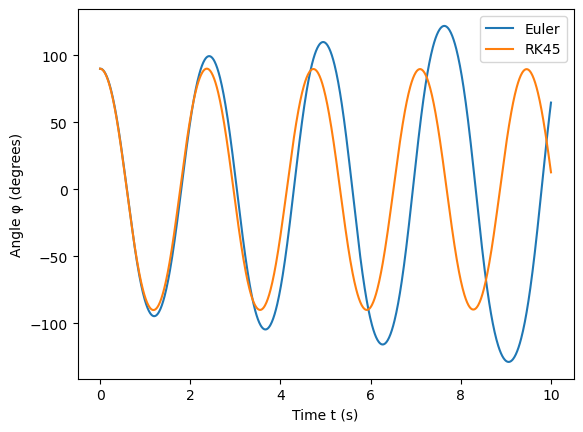

In [135]:
plt.plot(results_euler[0], results_euler[1], label = "Euler")
plt.plot(results_scipy[0], results_scipy[1], label = "RK45")

plt.xlabel('Time t (s)')
plt.ylabel('Angle φ (degrees)')

plt.legend()

plt.show()
plt.close()


# Obervations

- The two solutions already diverge noticeably after half of the total simulation time. This is due to the Euler method approximating the next state using only the derivative at the beginning of an interval. RK45, on the other hand, incorporates changes within a step via weighted averaging of multiple points, resulting in a significantly more accurate approximation.
- Another consequence of the Euler method's numerical error is that it leads to amplitude growth over time, which is unphysical. In extreme cases this can even lead to enough artificial energy for the pendulum to stop oscillating altogether.

These observations can be further highlighted by increasing the step size (dt):


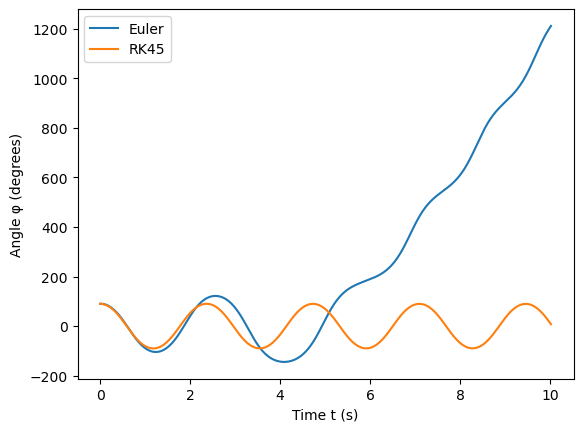

In [136]:
dt = 0.03       # step size (s)
t_total = 10.0  # total time (s)

results_euler = pendulum_euler(phi_0, omega_0, g, l, dt, t_total)
results_scipy = pendulum_scipy(phi_0, omega_0, g, l, dt, t_total)

plt.plot(results_euler[0], results_euler[1], label = "Euler")
plt.plot(results_scipy[0], results_scipy[1], label = "RK45")

plt.xlabel('Time t (s)')
plt.ylabel('Angle φ (degrees)')

plt.legend()

plt.show()
plt.close()

================================================================================================================================================================================

(b) A so called ”feed-forward” network motif is described as follows: (s. Abbildung 1). You can model the network sketched on the left side using several ”update” functions (middle) and (right). Discuss the diﬀerences of independent influence of in and m on out as compared to in and m
combined onto out. Document your analysis e.g. using Jupyter.

In [ ]:
def f(x):

    y = x

    return y

def g(x):

    y = x

    return y

def h(x):

    y = x

    return y

def unrelated(input):

    output = g(f(input))

    return output